## TREINAMENTO - REDE NEURAL

**Objetivo:** Treinar um modelo de rede neural para predição de abandono de tratamento de tuberculose (LTFU).

**Estratégia de avaliação:**
- **Rodada 1:** treino → teste1 (validação interna, mesma distribuição)
- **Rodada 2:** treino + teste1 → teste2 (validação externa, distribuição diferente)

**Métricas principais:**
- **Recall (classe 1):** minimizar falsos negativos (pacientes em risco não detectados)
- **F1-score:** equilíbrio entre precisão e recall
- **ROC-AUC:** capacidade discriminativa geral

In [58]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers, regularizers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.utils import class_weight
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
#Carregar os dados

BASE = '/content/drive/MyDrive/'

X_train = pd.read_csv(BASE + 'X_train_proc.csv')
X_test  = pd.read_csv(BASE + 'X_test_proc.csv')
y_train = pd.read_csv(BASE + 'y_train.csv').squeeze()
y_test  = pd.read_csv(BASE + 'y_test.csv').squeeze()

# Rodada 2: treino + teste1 juntos
X_train2 = pd.concat([X_train, X_test], ignore_index=True)
y_train2 = pd.concat([y_train, y_test], ignore_index=True)

# Teste2 - conjunto externo (dados de 2025)
X_test2 = pd.read_csv(BASE + 'X_test2_proc.csv')
y_test2 = pd.read_csv(BASE + 'y_test2.csv').squeeze()

X_train_np = X_train.values.astype('float32')
X_test_np  = X_test.values.astype('float32')
X_train2_np = X_train2.values.astype('float32')
X_test2_np  = X_test2.values.astype('float32')

y_train_np = y_train.values
y_test_np  = y_test.values
y_train2_np = y_train2.values
y_test2_np  = y_test2.values

print(f'X_train : {X_train_np.shape}')
print(f'X_test1 : {X_test_np.shape}')
print(f'X_train2: {X_train2_np.shape} ')
print(f'X_test2 : {X_test2_np.shape}')
print(f'\nTaxa abandono — treino: {y_train_np.mean()*100:.1f}% | teste1: {y_test_np.mean()*100:.1f}% | teste2: {y_test2_np.mean()*100:.1f}%')

X_train : (450105, 25)
X_test1 : (112527, 25)
X_train2: (562632, 25) 
X_test2 : (631, 25)

Taxa abandono — treino: 19.4% | teste1: 19.4% | teste2: 69.4%


In [60]:
# Class weights

pesos = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)
pesos_dict = dict(enumerate(pesos))
print(f'Class weights: {pesos_dict}')

# Sample weights: reingressos com peso 3x
# TRATAMENTO=3 (reingresso) após OrdinalEncoder vira índice 2.0
col_trat = X_train.columns.get_loc('TRATAMENTO')

def calcular_sample_weight(X_np, y_np, pesos_dict, col_trat, peso_reing=3.0):
    sw = np.where(y_np == 1, pesos_dict[1], pesos_dict[0]).astype('float32')
    mask_reing = (X_np[:, col_trat] == 2.0)
    sw[mask_reing] *= peso_reing
    n_reing = mask_reing.sum()
    print(f'  Reingressos: {n_reing} ({n_reing/len(X_np)*100:.1f}%) com peso {peso_reing}x extra')
    return sw

print('\nSample weights — Rodada 1:')
sw_train = calcular_sample_weight(X_train_np, y_train_np, pesos_dict, col_trat)

print('Sample weights — Rodada 2:')
col_trat2 = X_train2.columns.get_loc('TRATAMENTO')
sw_train2 = calcular_sample_weight(X_train2_np, y_train2_np, pesos_dict, col_trat2)

Class weights: {0: np.float64(0.6204887207680134), 1: np.float64(2.5748830131688845)}

Sample weights — Rodada 1:
  Reingressos: 46529 (10.3%) com peso 3.0x extra
Sample weights — Rodada 2:
  Reingressos: 58090 (10.3%) com peso 3.0x extra


In [61]:
# Função de Avaliação

def avaliar(nome, y_true, y_pred, y_prob):
    print(f'\n{"="*55}')
    print(f'  {nome}')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred,
                                 target_names=['Não abandona (0)', 'Abandona (1)']))
    auc = roc_auc_score(y_true, y_prob)
    print(f'ROC-AUC: {auc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=axes[0],
        display_labels=['Não abandona', 'Abandona'],
        colorbar=False
    )
    axes[0].set_title(f'Matriz de Confusão — {nome}')
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=axes[1])
    axes[1].set_title(f'Curva ROC — {nome} (AUC={auc:.3f})')
    axes[1].plot([0,1],[0,1],'--', color='gray')
    plt.tight_layout()
    plt.show()
    return auc

def plotar_curvas(historico, titulo):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(historico.history['loss'], label='treino')
    axes[0].plot(historico.history['val_loss'], label='validação')
    axes[0].set_title(f'Loss — {titulo}')
    axes[0].legend()
    axes[0].grid(True)
    axes[1].plot(historico.history['auc'], label='treino')
    axes[1].plot(historico.history['val_auc'], label='validação')
    axes[1].set_title(f'AUC — {titulo}')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()
    melhor = max(historico.history['val_auc'])
    epoca  = np.argmax(historico.history['val_auc']) + 1
    print(f'Melhor val_auc: {melhor:.4f} (época {epoca})')

print('Funções definidas!')

Funções definidas!


In [62]:
# Definição do modelo

def criar_modelo(n_features):
    modelo = keras.Sequential([
        layers.Input(shape=(n_features,)),

        # Camada 1
        layers.Dense(256, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Camada 2
        layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        # Camada 3
        layers.Dense(64, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.1),

        # Camada 4
        layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        # Saída
        layers.Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return modelo

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.1,
    patience=5,
    min_lr=1e-8,
    verbose=1,
    mode='max'
)

print('Arquitetura definida!')
criar_modelo(X_train_np.shape[1]).summary()

Arquitetura definida!


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_92 (Dense)                │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,841 (202.50 KB)

 Trainable params: 50,881 (198.75 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 70s 88ms/step - auc: 0.7400 - loss: 0.7660 - val_auc: 0.7542 - val_loss: 0.5835 - learning_rate: 1.0000e-04
Epoch 2/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 85s 107ms/step - auc: 0.7427 - loss: 0.7610 - val_auc: 0.7563 - val_loss: 0.5862 - learning_rate: 1.0000e-04
Epoch 3/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 102s 129ms/step - auc: 0.7432 - loss: 0.7591 - val_auc: 0.7558 - val_loss: 0.5966 - learning_rate: 1.0000e-04
Epoch 4/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 125s 158ms/step - auc: 0.7433 - loss: 0.7592 - val_auc: 0.7560 - val_loss: 0.5800 - learning_rate: 1.0000e-04
Epoch 5/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 136s 171ms/step - auc: 0.7439 - loss: 0.7577 - val_auc: 0.7556 - val_loss: 0.5937 - learning_rate: 1.0000e-04
Epoch 6/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 145s 183ms/step - auc: 0.7446 - loss: 0.7564 - val_auc: 0.7564 - val_loss: 0.5806 - learning_rate: 1.0000e-04
Epoch 7/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 147s 186ms/step - auc: 0.7451 - loss: 0.7555 - val_auc: 0.7574 

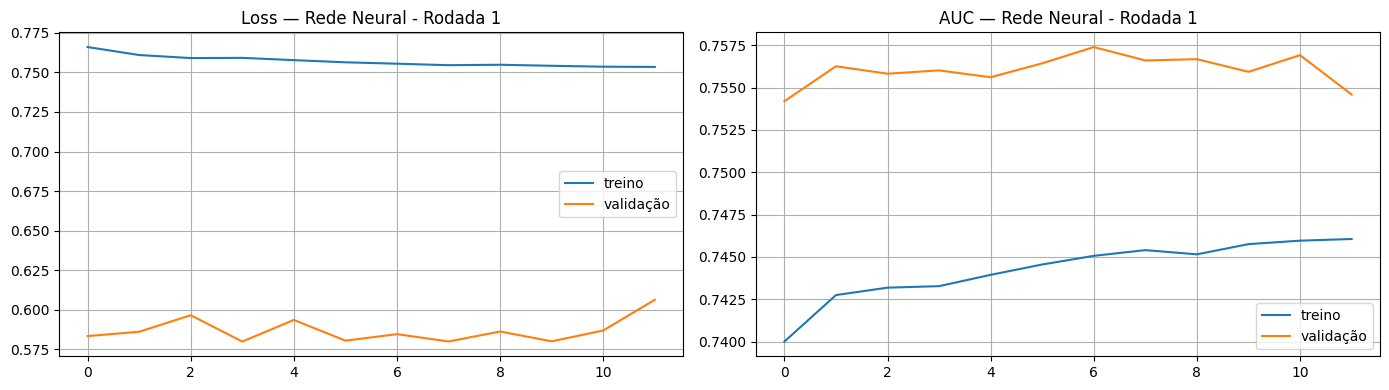

Melhor val_auc: 0.7574 (época 7)


In [71]:
# RODADA 1: treino -> teste1

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val, sw_tr, sw_val = train_test_split(
    X_train_np,
    y_train_np,
    sw_train,
    test_size=0.1,
    stratify=y_train_np,
    random_state=42
)

historico = modelo_RN.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    sample_weight=sw_tr,
    epochs=50,
    batch_size=512,
    callbacks=[early_stop, reduce_lr]
)

plotar_curvas(historico, 'Rede Neural - Rodada 1')



  Rede Neural - Teste 1
                  precision    recall  f1-score   support

Não abandona (0)       0.88      0.82      0.85     90676
    Abandona (1)       0.42      0.53      0.47     21851

        accuracy                           0.76    112527
       macro avg       0.65      0.67      0.66    112527
    weighted avg       0.79      0.76      0.77    112527

ROC-AUC: 0.7467


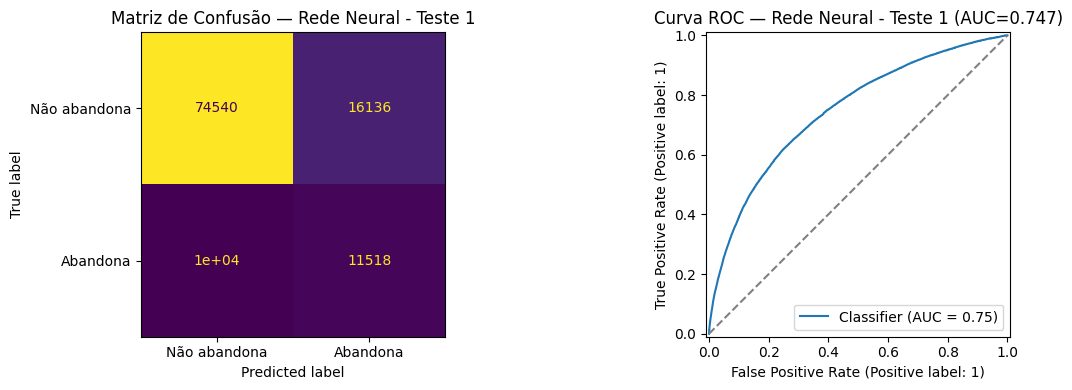

In [64]:
prob_test1 = modelo_RN.predict(X_test_np, verbose=0).flatten()
pred_test1 = (prob_test1 >= 0.5).astype(int)
auc1 = avaliar('Rede Neural - Teste 1', y_test_np, pred_test1, prob_test1)

Epoch 1/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 50s 50ms/step - auc: 0.6960 - loss: 0.9451 - val_auc: 0.7157 - val_loss: 0.8423 - learning_rate: 0.0010
Epoch 2/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 52s 53ms/step - auc: 0.7194 - loss: 0.8069 - val_auc: 0.7385 - val_loss: 0.8085 - learning_rate: 0.0010
Epoch 3/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 51s 52ms/step - auc: 0.7217 - loss: 0.7892 - val_auc: 0.7427 - val_loss: 0.8041 - learning_rate: 0.0010
Epoch 4/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 57s 58ms/step - auc: 0.7239 - loss: 0.7842 - val_auc: 0.7320 - val_loss: 0.8128 - learning_rate: 0.0010
Epoch 5/50
989/989 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - auc: 0.7248 - loss: 0.7820
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
989/989 ━━━━━━━━━━━━━━━━━━━━ 49s 49ms/step - auc: 0.7252 - loss: 0.7816 - val_auc: 0.7375 - val_loss: 0.8010 - learning_rate: 0.0010


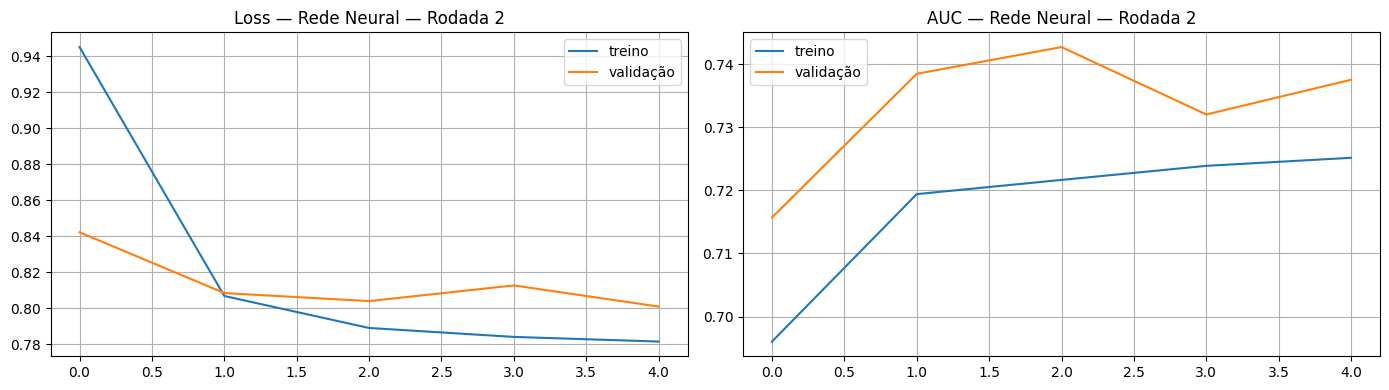

Melhor val_auc: 0.7427 (época 3)


In [65]:
# RODADA 2: treino + teste1 -> teste2

modelo_RN2 = criar_modelo(X_train2_np.shape[1])

historico2 = modelo_RN2.fit(
    X_train2_np, y_train2_np,
    validation_split=0.1,
    epochs=50,
    batch_size=512,
    sample_weight=sw_train2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plotar_curvas(historico2, 'Rede Neural — Rodada 2')
hist2_df = pd.DataFrame(historico2.history)



  Rede Neural — Teste 2
                  precision    recall  f1-score   support

Não abandona (0)       0.31      0.05      0.09       193
    Abandona (1)       0.69      0.95      0.80       438

        accuracy                           0.68       631
       macro avg       0.50      0.50      0.45       631
    weighted avg       0.58      0.68      0.58       631

ROC-AUC: 0.4634


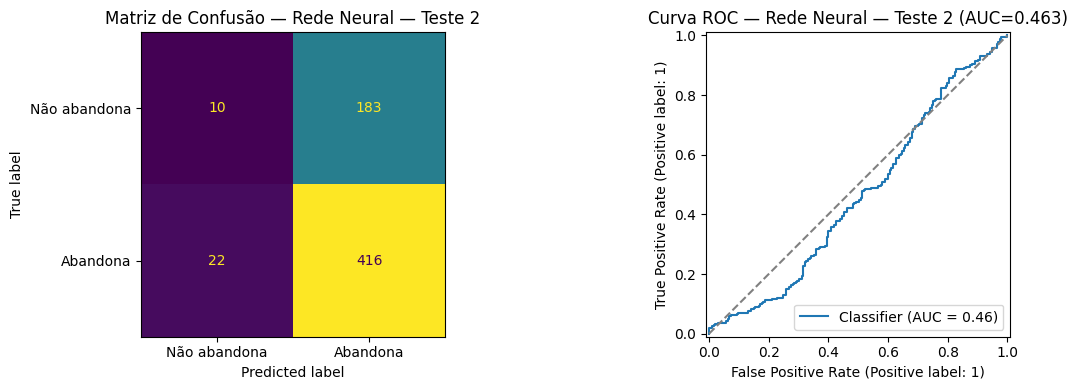

In [66]:
prob_test2 = modelo_RN2.predict(X_test2_np, verbose=0).flatten()
pred_test2 = (prob_test2 >= 0.5).astype(int)
auc2 = avaliar('Rede Neural — Teste 2', y_test2_np, pred_test2, prob_test2)

Calculando Permutation Importance...
Concluído!


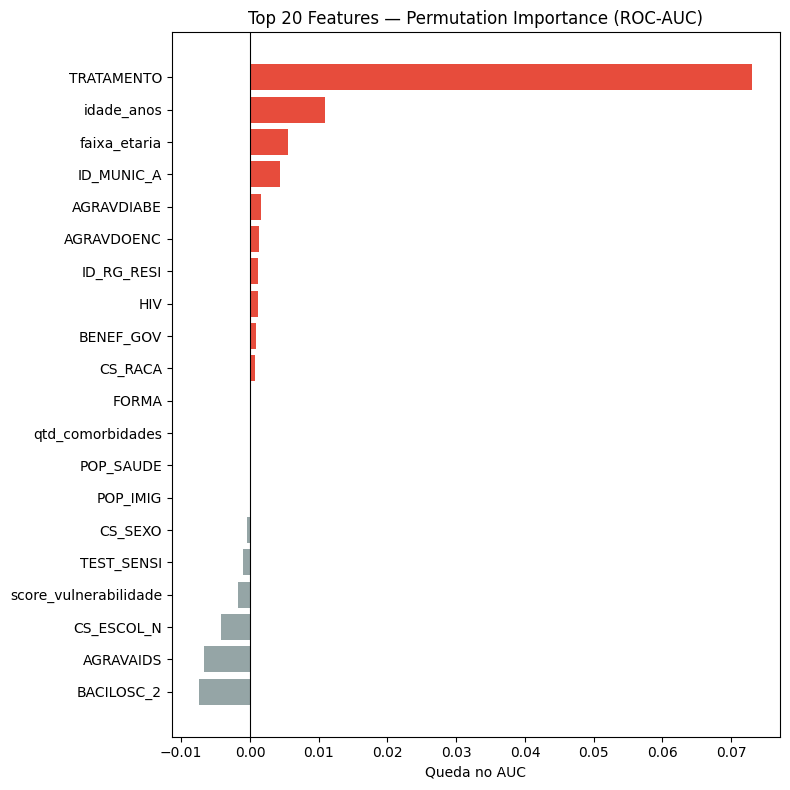


Top 10 features:
     feature  importancia
  TRATAMENTO       0.0731
  idade_anos       0.0109
faixa_etaria       0.0056
  ID_MUNIC_A       0.0043
  AGRAVDIABE       0.0016
  AGRAVDOENC       0.0014
  ID_RG_RESI       0.0012
         HIV       0.0012
   BENEF_GOV       0.0009
     CS_RACA       0.0007


In [74]:
# Explicabilidade - Permutation Importance

class KerasWrapper:
    def __init__(self, model):
        self.model = model
        self._estimator_type = 'classifier'

    def fit(self, X, y):
        return self

    def predict(self, X):
        return self.model.predict(X, verbose=0)

    def score(self, X, y):
        preds = self.predict(X)
        return roc_auc_score(y, preds)

sample_size = 2000
idx = np.random.choice(len(X_test2_np), sample_size)
X_sample = X_test2_np[idx]
y_sample = y_test2_np[idx]

print('Calculando Permutation Importance...')
result = permutation_importance(
    KerasWrapper(modelo_RN2),
    X_sample, y_sample,
    n_repeats=10,
    random_state=42,
    scoring=None
)
print('Concluído!')

df_imp = pd.DataFrame({
    'feature':     X_test2.columns.tolist(),
    'importancia': result.importances_mean
})
df_imp = df_imp.sort_values('importancia', ascending=False).reset_index(drop=True)

top20 = df_imp.head(20)
plt.figure(figsize=(8, 8))
plt.barh(top20['feature'][::-1], top20['importancia'][::-1],
         color=['#e74c3c' if v > 0 else '#95a5a6' for v in top20['importancia'][::-1]])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features — Permutation Importance (ROC-AUC)')
plt.xlabel('Queda no AUC')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(df_imp.head(10).to_string(index=False))
df_imp.to_csv(
    'permutation_importance.csv',
    index=False
)

In [73]:
from sklearn.metrics import f1_score, recall_score, precision_score

def resumo_metricas(nome, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Modelo': nome,
        'Recall':    recall_score(y_true, y_pred),
        'Precisão':  precision_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'ROC-AUC':   roc_auc_score(y_true, y_prob)
    }

pd.options.display.float_format = '{:.4f}'.format
resultados = pd.DataFrame([
    resumo_metricas('Rodada 1 — Teste1', y_test_np,  prob_test1),
    resumo_metricas('Rodada 2 — Teste2', y_test2_np, prob_test2),
])
resultados.to_csv(
    'resultados_rede_neural.csv',
    index=False
)
print(resultados.to_string(index=False))

           Modelo  Recall  Precisão     F1  ROC-AUC
Rodada 1 — Teste1  0.5271    0.4165 0.4653   0.7467
Rodada 2 — Teste2  0.9498    0.6945 0.8023   0.4634


In [75]:
#Salvar modelos

modelo_RN2.save('/content/drive/MyDrive/modelo_RN.keras')
joblib.dump(top20, '/content/drive/MyDrive/top_features_RN.pkl')
print('modelo_RN.keras salvo!')

modelo_RN.keras salvo!
